基于注意力机制的 Seq2Seq 机器翻译

本 notebook 用一个小型中英数据集演示 Encoder、Attention 和 Decoder 的完整流程。

**模型流程：** 中文序列 → GRU Encoder → 隐藏状态与编码器输出 → Attention → GRU Decoder → 英文序列

训练阶段会给 Decoder 正确答案的一部分（teacher forcing），让模型逐步学习；验证和实际生成时不再提供正确答案。

In [1]:
import os
import random
import warnings

warnings.filterwarnings("ignore", message="The pynvml package is deprecated.*", category=FutureWarning)

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F

random.seed(42)
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({"font.sans-serif": ["Microsoft YaHei", "SimHei", "DejaVu Sans"], "axes.unicode_minus": False, "figure.dpi": 120})
print("PyTorch 版本：", torch.__version__)
print("运行设备：", device)

PyTorch 版本： 2.8.0+cpu
运行设备： cpu


In [2]:
src_vocab = {"<pad>": 0, "<bos>": 1, "<eos>": 2, "我": 3, "喜欢": 4, "学习": 5, "自然": 6, "语言": 7, "处理": 8}
tgt_vocab = {"<pad>": 0, "<bos>": 1, "<eos>": 2, "I": 3, "like": 4, "learning": 5, "natural": 6, "language": 7, "processing": 8, "learn": 9}
src_id_to_word = {index: word for word, index in src_vocab.items()}
tgt_id_to_word = {index: word for word, index in tgt_vocab.items()}
print("源词表：", src_vocab)
print("目标词表：", tgt_vocab)
#<bos>句子开始    <eos>句子结束   <pad>补齐长度

源词表： {'<pad>': 0, '<bos>': 1, '<eos>': 2, '我': 3, '喜欢': 4, '学习': 5, '自然': 6, '语言': 7, '处理': 8}
目标词表： {'<pad>': 0, '<bos>': 1, '<eos>': 2, 'I': 3, 'like': 4, 'learning': 5, 'natural': 6, 'language': 7, 'processing': 8, 'learn': 9}


In [3]:
class Encoder(nn.Module):
    """编码器：把输入句子转换成隐藏语义信息。负责把中文读懂并转换成机器内部的语义表示。"""

    def __init__(self, vocab_size, embedding_dim, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.gru = nn.GRU(embedding_dim, hidden_size, batch_first=True)
        # vocab_size词表大小。embedding_dim词向量维度。hidden_size隐藏状态大小。

    def forward(self, src):
        embedded = self.embedding(src)
        outputs, hidden = self.gru(embedded)
        return outputs, hidden, embedded
print("Encoder定义完成")

Encoder定义完成


In [4]:
class DotAttention(nn.Module):
    """实现注意力机制。"""

    def forward(self, decoder_hidden, encoder_outputs, src_mask=None):
        query = decoder_hidden[-1].unsqueeze(1)
        scores = torch.bmm(query, encoder_outputs.transpose(1, 2)).squeeze(1)

        if src_mask is not None:
            scores = scores.masked_fill(src_mask == 0, -1e9)

        weights = F.softmax(scores, dim=-1)
        context = torch.bmm(weights.unsqueeze(1), encoder_outputs).squeeze(1)

        return context, weights


print("点积注意力定义完成")

点积注意力定义完成


In [5]:
class AttentionDecoder(nn.Module):
    """根据Encoder信息生成目标语言。根据 Encoder 的中文信息，一个词一个词产生英文。"""

    def __init__(self, vocab_size, embedding_dim, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.attention = DotAttention()
        self.gru = nn.GRU(embedding_dim + hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size * 2, vocab_size)

    def forward(self, input_token, hidden, encoder_outputs, src_mask=None):
        embedded = self.embedding(input_token).unsqueeze(1)
        context, weights = self.attention(hidden, encoder_outputs, src_mask)
        gru_input = torch.cat([embedded, context.unsqueeze(1)], dim=-1)
        output, hidden = self.gru(gru_input, hidden)
        logits = self.fc(torch.cat([output.squeeze(1), context], dim=-1))
        return logits, hidden, weights, embedded


print("AttentionDecoder定义完成")

AttentionDecoder定义完成


In [6]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, bos_id=1, eos_id=2):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.bos_id = bos_id
        self.eos_id = eos_id

    def forward(self, src, tgt, teacher_forcing_ratio=1.0):
        encoder_outputs, hidden, src_embeddings = self.encoder(src)
        src_mask = (src != 0)
        input_token = tgt[:, 0]
        all_logits = []
        all_attentions = []

        for step in range(1, tgt.size(1)):
            logits, hidden, weights, _ = self.decoder(
                input_token, hidden, encoder_outputs, src_mask
            )
            all_logits.append(logits.unsqueeze(1))
            all_attentions.append(weights.unsqueeze(1))

            predicted = logits.argmax(dim=-1)
            input_token = tgt[:, step] if random.random() < teacher_forcing_ratio else predicted

        return (
            torch.cat(all_logits, dim=1),
            torch.cat(all_attentions, dim=1),
            encoder_outputs,
            src_embeddings,
        )


embedding_dim, hidden_size = 16, 32
seq2seq = Seq2Seq(
    Encoder(len(src_vocab), embedding_dim, hidden_size),
    AttentionDecoder(len(tgt_vocab), embedding_dim, hidden_size)
).to(device)
print(seq2seq)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(9, 16, padding_idx=0)
    (gru): GRU(16, 32, batch_first=True)
  )
  (decoder): AttentionDecoder(
    (embedding): Embedding(10, 16, padding_idx=0)
    (attention): DotAttention()
    (gru): GRU(48, 32, batch_first=True)
    (fc): Linear(in_features=64, out_features=10, bias=True)
  )
)


## 2. 准备小型训练集与独立验证集

训练集包含 4 个不同句式，验证句子不参与参数更新。批次使用 `<pad>` 补齐，损失函数会忽略这些填充位置。

In [7]:
def encode_tokens(tokens, vocab):
    return [vocab["<bos>"]] + [vocab[token] for token in tokens] + [vocab["<eos>"]]


def make_batch(pairs):
    src_sequences = [encode_tokens(source, src_vocab) for source, _ in pairs]
    tgt_sequences = [encode_tokens(target, tgt_vocab) for _, target in pairs]
    src_length, tgt_length = max(map(len, src_sequences)), max(map(len, tgt_sequences))
    src_batch = [sequence + [src_vocab["<pad>"]] * (src_length - len(sequence)) for sequence in src_sequences]
    tgt_batch = [sequence + [tgt_vocab["<pad>"]] * (tgt_length - len(sequence)) for sequence in tgt_sequences]
    return torch.tensor(src_batch, device=device), torch.tensor(tgt_batch, device=device)


train_pairs = [
    (["我", "喜欢", "学习"], ["I", "like", "learning"]),
    (["我", "喜欢", "自然", "语言", "处理"], ["I", "like", "natural", "language", "processing"]),
    (["我", "学习", "语言", "处理"], ["I", "learn", "language", "processing"]),
    (["自然", "语言", "处理"], ["natural", "language", "processing"]),
]
valid_pairs = [(["我", "学习", "自然", "语言"], ["I", "learn", "natural", "language"])]
train_src, train_tgt = make_batch(train_pairs)
valid_src, valid_tgt = make_batch(valid_pairs)
src, tgt = train_src[1:2], train_tgt[1:2]
print(f"训练批次形状：{train_src.shape} → {train_tgt.shape}")
print(f"验证批次形状：{valid_src.shape} → {valid_tgt.shape}")
print("展示样本：", [src_id_to_word[index.item()] for index in src[0] if index.item() != src_vocab["<pad>"]])

训练批次形状：torch.Size([4, 7]) → torch.Size([4, 7])
验证批次形状：torch.Size([1, 6]) → torch.Size([1, 6])
展示样本： ['<bos>', '我', '喜欢', '自然', '语言', '处理', '<eos>']


## 3. 第一次前向传播：查看每个阶段的形状

In [8]:
logits, attentions, encoder_outputs, src_embeddings = seq2seq(src, tgt, teacher_forcing_ratio=1.0)
print(f"词嵌入：{src_embeddings.shape}；编码器输出：{encoder_outputs.shape}")
print(f"解码器 Logits：{logits.shape}；注意力矩阵：{attentions.shape}")
print("每一步注意力权重和：", attentions.sum(dim=-1))

词嵌入：torch.Size([1, 7, 16])；编码器输出：torch.Size([1, 7, 32])
解码器 Logits：torch.Size([1, 6, 10])；注意力矩阵：torch.Size([1, 6, 7])


每一步注意力权重和： tensor([[1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]],
       grad_fn=<SumBackward1>)


## 4. 计算损失并完成一次反向传播

In [9]:
criterion = nn.CrossEntropyLoss(ignore_index=tgt_vocab["<pad>"], label_smoothing=0.08)
optimizer = torch.optim.AdamW(seq2seq.parameters(), lr=0.004, weight_decay=1e-4)
target_for_loss = tgt[:, 1:]
loss = criterion(logits.reshape(-1, logits.size(-1)), target_for_loss.reshape(-1))
optimizer.zero_grad()
loss.backward()
gradient_norm = nn.utils.clip_grad_norm_(seq2seq.parameters(), max_norm=1.0)
optimizer.step()
print(f"一次训练损失：{loss.item():.4f}")
print(f"裁剪前梯度范数：{gradient_norm.item():.4f}")

一次训练损失：2.3210
裁剪前梯度范数：0.6936


## 5. 可靠地观察训练与验证损失

单一样本配合 100% teacher forcing 时，模型会直接记住答案，训练损失接近 0 并不奇怪，但不能代表泛化能力。这里在正式训练前重置模型，并采用：

- 训练集平均损失与独立验证损失同时记录；
- `label_smoothing=0.08`，避免模型把正确词概率推到不现实的 100%；
- 梯度裁剪和学习率调度，减少小数据训练的剧烈震荡；
- teacher forcing 从 1.0 逐步降至 0.5，使训练更接近实际生成。

In [10]:
random.seed(42)
torch.manual_seed(42)
seq2seq = Seq2Seq(Encoder(len(src_vocab), embedding_dim, hidden_size), AttentionDecoder(len(tgt_vocab), embedding_dim, hidden_size)).to(device)
optimizer = torch.optim.AdamW(seq2seq.parameters(), lr=0.004, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.6, patience=18, min_lr=5e-4)
num_epochs = 160
train_loss_history, valid_loss_history = [], []

for epoch in range(num_epochs):
    teacher_forcing_ratio = max(0.5, 1.0 - epoch / 200)
    seq2seq.train()
    train_logits, _, _, _ = seq2seq(train_src, train_tgt, teacher_forcing_ratio)
    train_loss = criterion(train_logits.reshape(-1, train_logits.size(-1)), train_tgt[:, 1:].reshape(-1))
    optimizer.zero_grad()
    train_loss.backward()
    nn.utils.clip_grad_norm_(seq2seq.parameters(), max_norm=1.0)
    optimizer.step()

    seq2seq.eval()
    with torch.no_grad():
        valid_logits, _, _, _ = seq2seq(valid_src, valid_tgt, teacher_forcing_ratio=0.0)
        valid_loss = criterion(valid_logits.reshape(-1, valid_logits.size(-1)), valid_tgt[:, 1:].reshape(-1))
    scheduler.step(valid_loss)
    train_loss_history.append(train_loss.item())
    valid_loss_history.append(valid_loss.item())
    if (epoch + 1) % 20 == 0: print(f"Epoch {epoch + 1:3d}｜训练 {train_loss.item():.4f}｜验证 {valid_loss.item():.4f}｜TF {teacher_forcing_ratio:.2f}")

Epoch  20｜训练 1.0232｜验证 1.5865｜TF 0.91


Epoch  40｜训练 0.4842｜验证 1.3522｜TF 0.80


Epoch  60｜训练 0.4423｜验证 1.6577｜TF 0.71


Epoch  80｜训练 0.4319｜验证 1.7558｜TF 0.60


Epoch 100｜训练 0.4286｜验证 1.8384｜TF 0.51


Epoch 120｜训练 0.4271｜验证 1.8775｜TF 0.50
Epoch 140｜训练 0.4264｜验证 1.8993｜TF 0.50


Epoch 160｜训练 0.4256｜验证 1.9192｜TF 0.50


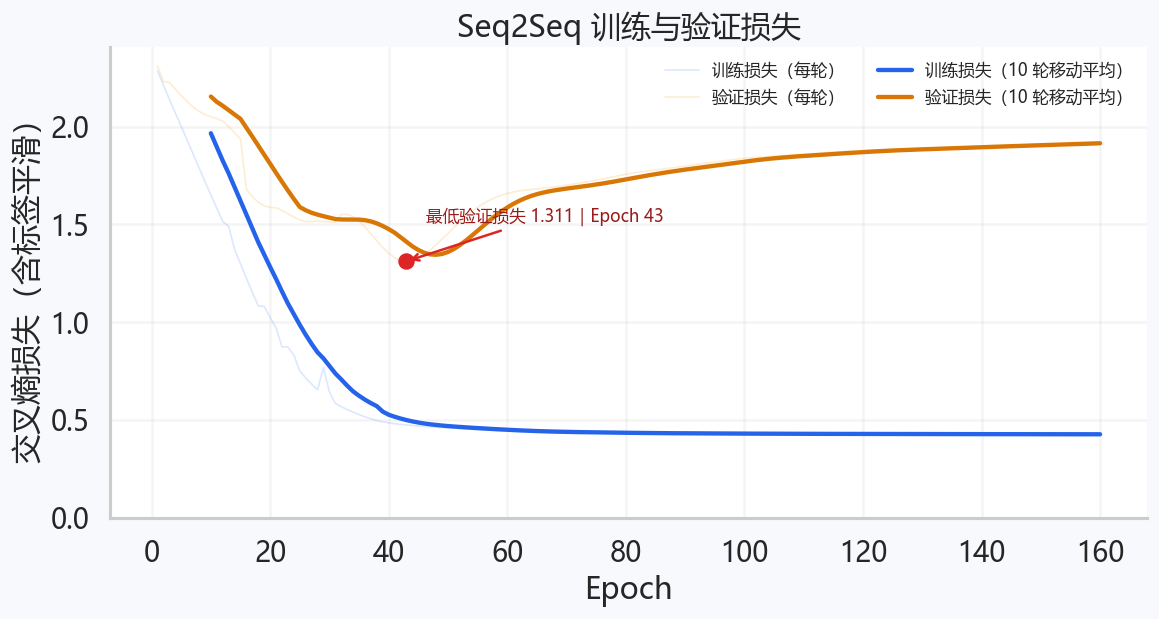

In [11]:
def moving_average(values, window=10):
    return np.convolve(values, np.ones(window) / window, mode="valid")


window = 10
epochs = np.arange(1, num_epochs + 1)
best_epoch = int(np.argmin(valid_loss_history)) + 1
best_valid_loss = valid_loss_history[best_epoch - 1]
fig, ax = plt.subplots(figsize=(10, 5.5), facecolor="#F7F9FC")
ax.plot(epochs, train_loss_history, color="#3B82F6", alpha=0.18, linewidth=1, label="训练损失（每轮）")
ax.plot(epochs, valid_loss_history, color="#F59E0B", alpha=0.18, linewidth=1, label="验证损失（每轮）")
ax.plot(epochs[window - 1:], moving_average(train_loss_history, window), color="#2563EB", linewidth=2.6, label=f"训练损失（{window} 轮移动平均）")
ax.plot(epochs[window - 1:], moving_average(valid_loss_history, window), color="#D97706", linewidth=2.6, label=f"验证损失（{window} 轮移动平均）")
ax.scatter(best_epoch, best_valid_loss, s=70, color="#DC2626", zorder=5)
ax.annotate(f"最低验证损失 {best_valid_loss:.3f}｜Epoch {best_epoch}", xy=(best_epoch, best_valid_loss), xytext=(12, 24), textcoords="offset points", fontsize=10, color="#991B1B", arrowprops={"arrowstyle": "->", "color": "#DC2626"})
ax.set(title="Seq2Seq 训练与验证损失", xlabel="Epoch", ylabel="交叉熵损失（含标签平滑）")
ax.set_ylim(bottom=0)
ax.legend(frameon=False, ncol=2, fontsize=10)
ax.grid(alpha=0.2)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()
''' Loss 越低通常越好,43之后模型对训练集越来越熟（蓝色下降）。橙色验证 Loss开始上升，模型虽然越来越会做训练数据，但是对没见过的数据反而越来越差。'''

## 6. 贪婪解码：不再提供正确目标词

In [12]:
def greedy_decode(model, src, max_len=12):
    model.eval()
    generated = [model.bos_id]
    attention_rows = []

    with torch.no_grad():
        encoder_outputs, hidden, _ = model.encoder(src)
        src_mask = (src != 0)
        input_token = torch.tensor([model.bos_id], device=src.device)

        for _ in range(max_len):
            logits, hidden, weights, _ = model.decoder(
                input_token, hidden, encoder_outputs, src_mask
            )
            next_id = logits.argmax(dim=-1).item()
            generated.append(next_id)
            attention_rows.append(weights.squeeze(0).cpu())

            if next_id == model.eos_id:
                break

            input_token = torch.tensor([next_id], device=src.device)

    return generated, torch.stack(attention_rows) if attention_rows else torch.empty(0)


generated_ids, generated_attention = greedy_decode(seq2seq, src)
print("生成编号：", generated_ids)
print("生成文本：", " ".join(tgt_id_to_word.get(i, "<?>") for i in generated_ids))
print("生成注意力形状：", generated_attention.shape)

生成编号： [1, 3, 4, 6, 7, 8, 2]
生成文本： <bos> I like natural language processing <eos>
生成注意力形状： torch.Size([6, 7])


## 7. 可视化解码器注意力

每一行对应一个生成词，每一列对应一个输入词；单元格数字是注意力权重，同一行的权重之和约为 1。

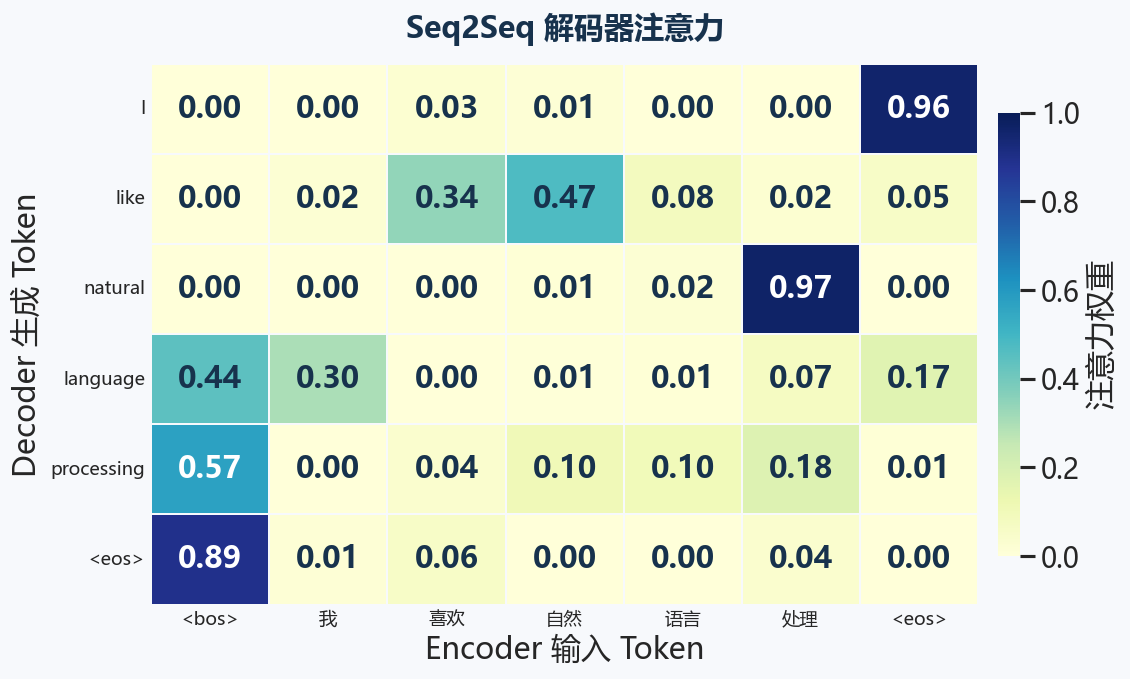

In [13]:
if generated_attention.numel() > 0:
    src_labels = [src_id_to_word[index.item()] for index in src[0]]
    tgt_labels = [tgt_id_to_word.get(index, "<?>") for index in generated_ids[1:]]
    attention_matrix = generated_attention.numpy()

    fig, ax = plt.subplots(
        figsize=(10, 6),
        facecolor="#F7F9FC"
    )

    sns.heatmap(
        attention_matrix,
        ax=ax,
        annot=True,
        fmt=".2f",
        cmap="YlGnBu",
        vmin=0,
        vmax=1,
        xticklabels=src_labels,
        yticklabels=tgt_labels,
        linewidths=1.2,
        linecolor="#F7F9FC",
        cbar_kws={
            "label": "注意力权重",
            "shrink": 0.82,
            "pad": 0.02
        }
    )

    threshold = (attention_matrix.min() + attention_matrix.max()) / 2
    for label, value in zip(ax.texts, attention_matrix.ravel()):
        label.set_color("white" if value >= threshold else "#17324D")
        label.set_fontweight("bold")

    ax.set_title(
        "Seq2Seq 解码器注意力",
        fontsize=18,
        fontweight="bold",
        color="#17324D",
        pad=16
    )
    ax.set(xlabel="Encoder 输入 Token", ylabel="Decoder 生成 Token")
    ax.tick_params(axis="both", length=0, labelsize=11)
    plt.setp(ax.get_xticklabels(), rotation=0)
    plt.setp(ax.get_yticklabels(), rotation=0)

    fig.tight_layout()
    plt.show()
else:
    print("没有可显示的注意力结果")

## 8. 模型下载说明

这个 Notebook 的 Seq2Seq 模型从零开始创建，不需要下载预训练模型。训练后可以本地保存：

In [14]:
save_path = os.path.join("data", "seq2seq_toy_local.pt")
os.makedirs(os.path.dirname(save_path), exist_ok=True)
torch.save({"model_state_dict": seq2seq.state_dict(), "src_vocab": src_vocab, "tgt_vocab": tgt_vocab}, save_path)
print("本地模型已保存：", os.path.abspath(save_path))
print(f"文件大小：{os.path.getsize(save_path) / 1024:.1f} KB")

本地模型已保存： D:\11\NLP\data\seq2seq_toy_local.pt
文件大小：58.4 KB


训练损失低于验证损失是正常现象；如果验证损失开始上升，说明模型正在过拟合。